# 07. Émotions et registres

Ce notebook analyse les **registres émotionnels** , la tonalité affective dominante du discours (indignation, défi, neutre, etc.) , et les **cadres discursifs** (primary frames), c’est-à-dire les schèmes d’interprétation mobilisés pour structurer le discours (humanitaire, sécuritaire, moral). On examine leur répartition par bloc, leur évolution temporelle et les associations bloc–registre. La méthode « fighting words » (Monroe et al., 2008) peut être mobilisée pour identifier les termes les plus distinctifs selon le registre émotionnel.

## Setup et configuration

Les bibliothèques et les deux versions du corpus sont chargés. Les variables de registre émotionnel et de cadre discursif proviennent du corpus par fenêtres événementielles.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, BATCH_ORDER, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## Chargement du corpus

Le corpus principal et le corpus par fenêtres événementielles sont chargés. Les colonnes de registre émotionnel et de cadre discursif sont présentes dans le second.

In [2]:
from config import CORPUS_V3, CORPUS_V4
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))

df_v4 = pd.read_parquet(CORPUS_V4)
df_v4['date'] = pd.to_datetime(df_v4['date'])
df_v4['month'] = df_v4['date'].dt.to_period('M').astype(str)

print(f"Corpus principal : {len(df):,} textes. Corpus par fenêtres événementielles : {len(df_v4):,} textes.")

Corpus principal : 10,774 textes. Corpus par fenêtres événementielles : 5,905 textes.


## Fig 41 : Registres émotionnels par bloc

Les registres émotionnels classent chaque texte selon sa tonalité dominante (indignation, défi, neutre, etc.). Le graphique en barres empilées montre la répartition de ces registres par bloc politique.

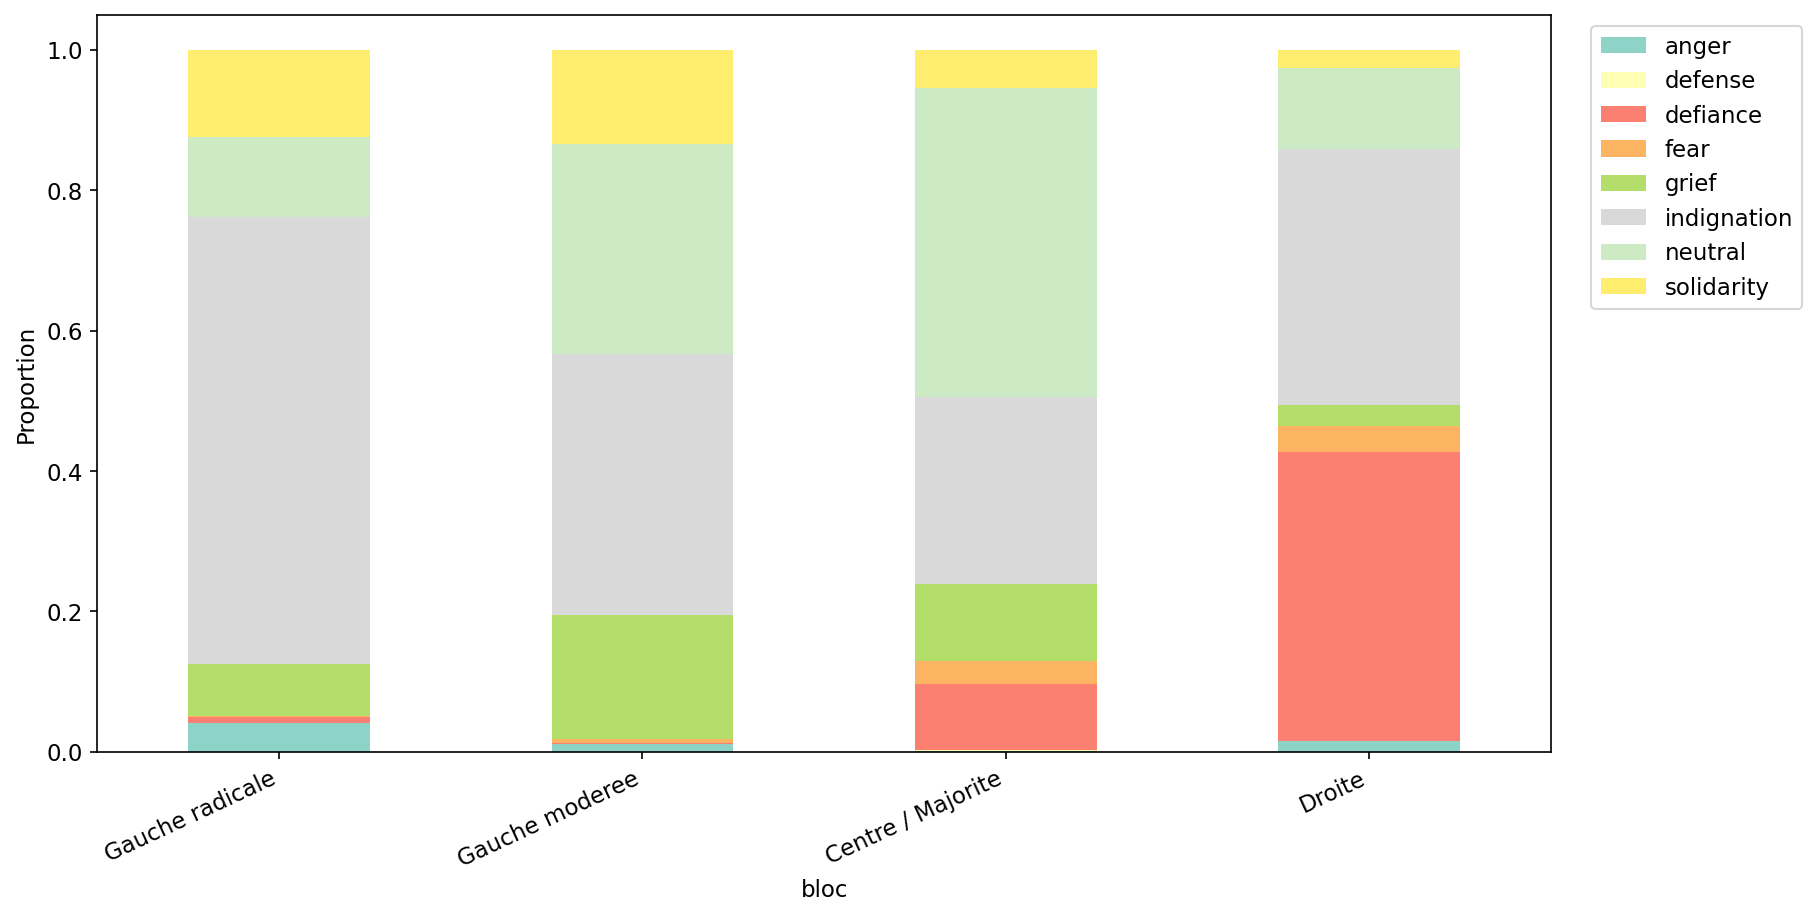

In [3]:
emo_col = 'emotional_register' if 'emotional_register' in df_v4.columns else 'emotional_reg' if 'emotional_reg' in df_v4.columns else None
if emo_col:
    emo = df_v4[df_v4['bloc'].isin(BLOC_ORDER)].groupby(['bloc', emo_col]).size().unstack(fill_value=0)
    emo_pct = emo.div(emo.sum(axis=1), axis=0)
    emo_pct = emo_pct.reindex(BLOC_ORDER)
    emo_pct.to_csv(RES_DIR / 'emotional_register.csv')
    fig, ax = plt.subplots(figsize=(12, 6))
    emo_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', legend=True)
    ax.legend(bbox_to_anchor=(1.02, 1))
    ax.set_ylabel('Proportion')
    plt.xticks(rotation=25, ha='right')
    save('fig41_emotional_register')
else:
    frame_col = 'primary_frame_v3' if 'primary_frame_v3' in df.columns else 'frame_primary' if 'frame_primary' in df_v4.columns else None
    fc = frame_col or 'primary_frame_v3'
    df_plot = df if fc in df.columns else df_v4
    if fc in df_plot.columns:
        fr = df_plot[df_plot['bloc'].isin(BLOC_ORDER)].groupby(['bloc', fc]).size().unstack(fill_value=0)
        fr_pct = fr.div(fr.sum(axis=1), axis=0).reindex(BLOC_ORDER)
        fig, ax = plt.subplots(figsize=(12, 6))
        fr_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
        save('fig41_emotional_register')
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, 'Pas de colonne emotional_register', ha='center', va='center')
        save('fig41_emotional_register')

L’indignation domine à gauche tandis que la Droite combine défi et indignation ; le Centre se singularise par une part plus élevée de registre neutre.

## Fig 42 : Cadres discursifs par bloc

Les cadres discursifs désignent les schèmes d’interprétation mobilisés pour présenter le conflit (humanitaire, sécuritaire, moral, etc.). On observe la répartition du cadre principal par bloc.

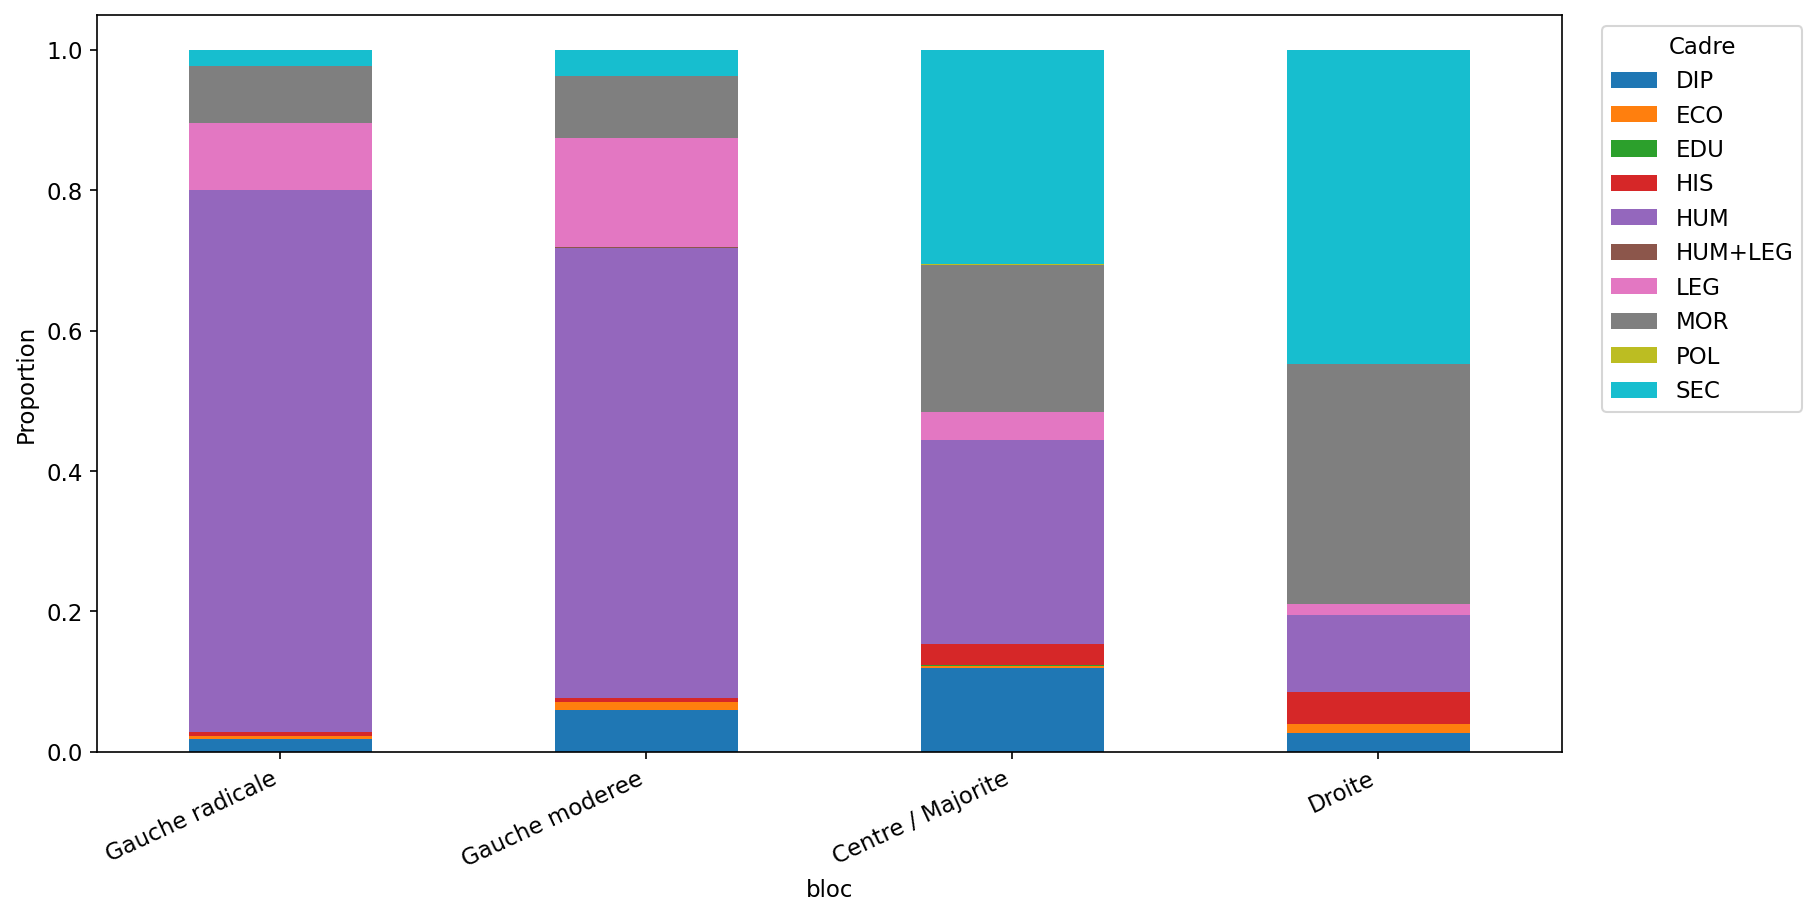

In [4]:
frame_col = 'primary_frame_v3' if 'primary_frame_v3' in df.columns else 'frame_primary' if 'frame_primary' in df_v4.columns else None
fc = frame_col or 'primary_frame_v3'
df_f = df if fc in df.columns else df_v4
if fc in df_f.columns:
    frames = df_f[df_f['bloc'].isin(BLOC_ORDER)].groupby(['bloc', fc]).size().unstack(fill_value=0)
    frames_pct = frames.div(frames.sum(axis=1), axis=0).reindex(BLOC_ORDER)
    frames_pct.to_csv(RES_DIR / 'frames_par_bloc.csv')
    fig, ax = plt.subplots(figsize=(12, 6))
    frames_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_ylabel('Proportion')
    plt.xticks(rotation=25, ha='right')
    ax.legend(title='Cadre', bbox_to_anchor=(1.02, 1))
    save('fig42_frames_par_bloc')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(BLOC_ORDER, df[df['bloc'].isin(BLOC_ORDER)].groupby('bloc')['stance_v3'].mean().reindex(BLOC_ORDER).values, color=[BLOC_COLORS[b] for b in BLOC_ORDER])
    save('fig42_frames_par_bloc')

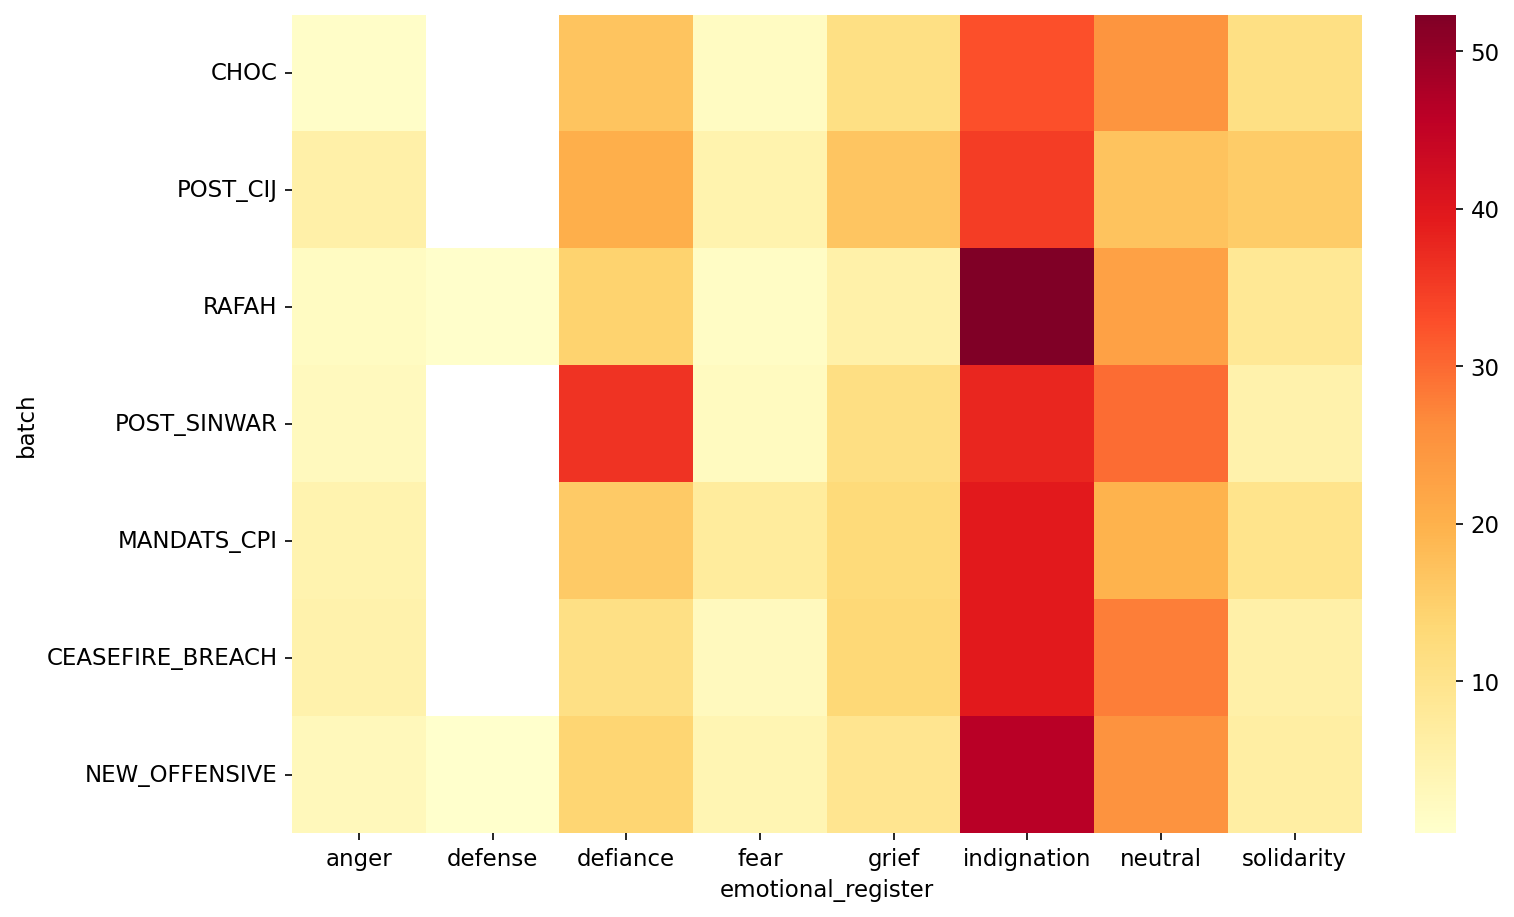

In [5]:
# Fig 43 : Registres par batch (heatmap)
reg_batch_path = RES_DIR / "emotional_register_v4.csv"
if not reg_batch_path.exists():
    reg_batch_path = Path(PROJECT_ROOT).parent / "fr_assemblee_discourse_analysis" / "data" / "results" / "emotional_register_v4.csv"
if reg_batch_path.exists():
    reb = pd.read_csv(reg_batch_path)
    piv = reb.pivot_table(index="batch", columns="emotional_register", values="pct", aggfunc="mean")
    piv = piv.reindex([b for b in BATCH_ORDER if b in piv.index])
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(piv, ax=ax, cmap="YlOrRd")
    save("fig43_registres_par_batch")

Le cadre humanitaire structure le discours de gauche ; le Centre et la Droite mobilisent davantage les cadres sécuritaire et moral.

## Fig 44 : Évolution des registres émotionnels (top 3)

L’évolution mensuelle de la part des trois registres les plus fréquents permet de repérer les inflexions temporelles dans la tonalité affective du discours.

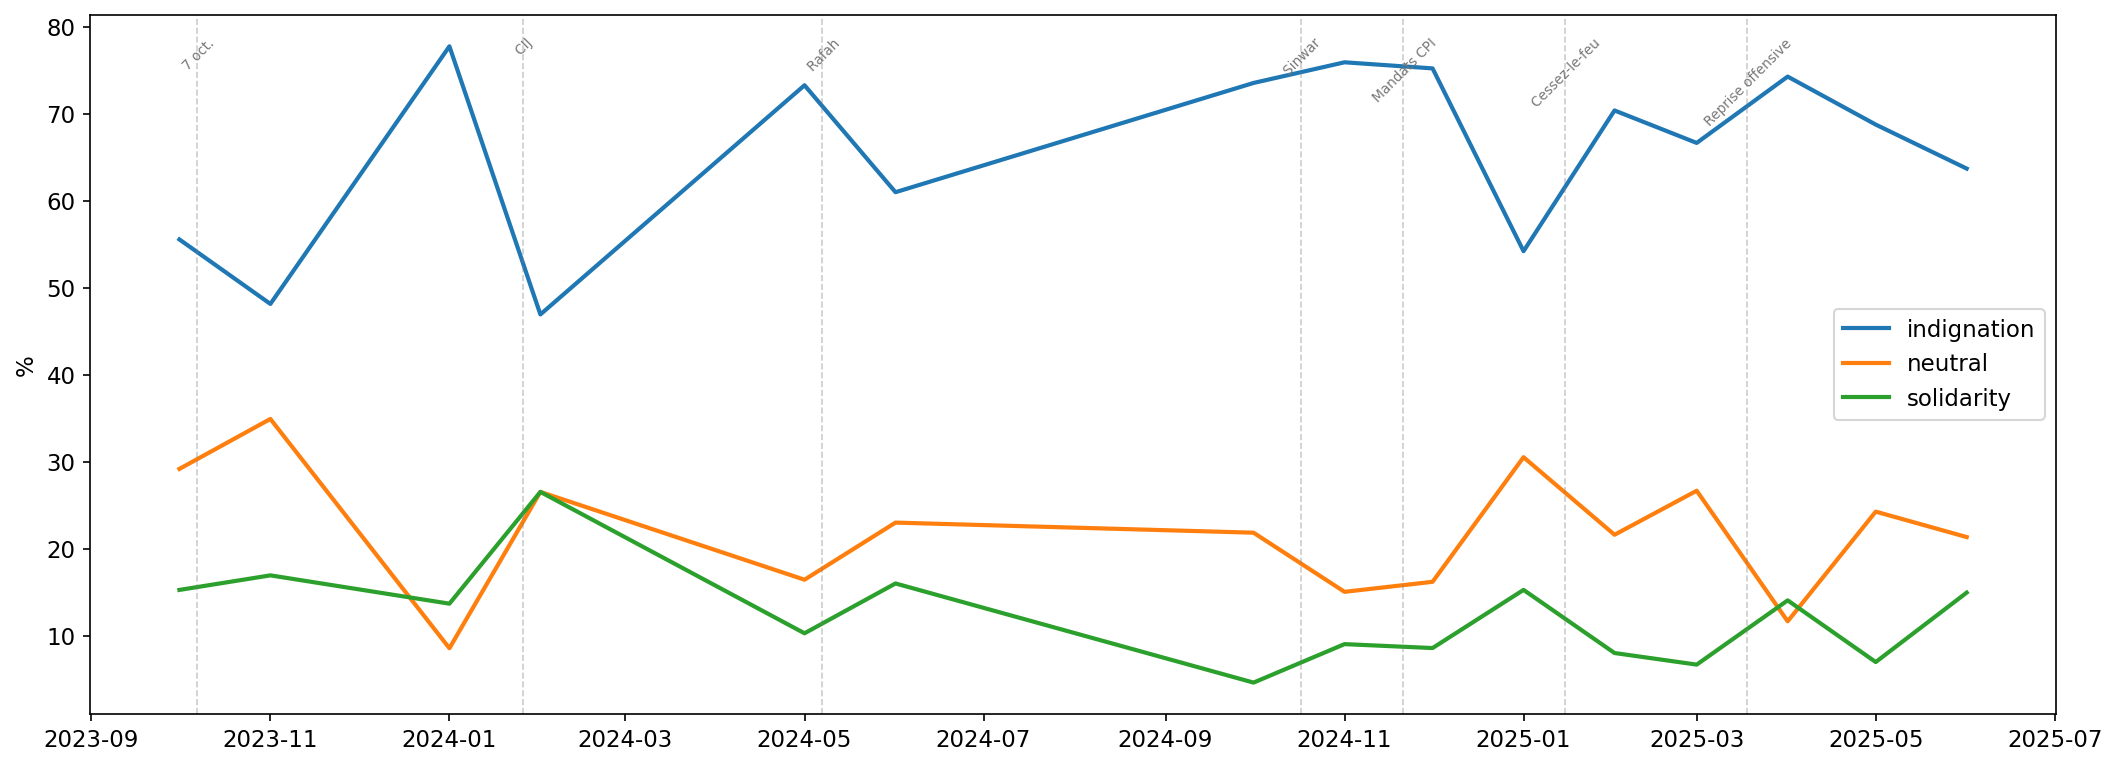

In [6]:
emo_col = 'emotional_register' if 'emotional_register' in df_v4.columns else ('emotional_reg' if 'emotional_reg' in df_v4.columns else None)
if emo_col and emo_col in df_v4.columns:
    top_reg = df_v4[emo_col].value_counts().head(3).index.tolist()
    emo_m = df_v4[df_v4[emo_col].isin(top_reg)].groupby(['month', emo_col]).size().unstack(fill_value=0)
    emo_m_pct = emo_m.div(emo_m.sum(axis=1), axis=0)
    emo_m_pct['month_ts'] = pd.to_datetime(emo_m_pct.index.astype(str) + '-01')
    fig, ax = plt.subplots(figsize=(14, 5))
    for reg in top_reg:
        if reg in emo_m_pct.columns:
            ax.plot(emo_m_pct['month_ts'], emo_m_pct[reg]*100, label=reg, lw=2)
    add_events(ax)
    ax.legend()
    ax.set_ylabel('%')
    save('fig44_emotions_temporelles')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    stance_m = df.groupby('month')['stance_v3'].mean()
    ax.plot(pd.to_datetime(stance_m.index.astype(str)+'-01'), stance_m.values)
    save('fig44_emotions_temporelles')

## Fig 45 : Concordance FEEL / LLM (ou heatmap registres × blocs)

La carte thermique croise les blocs politiques et les registres émotionnels. Les couleurs indiquent la proportion de chaque registre au sein de chaque bloc.

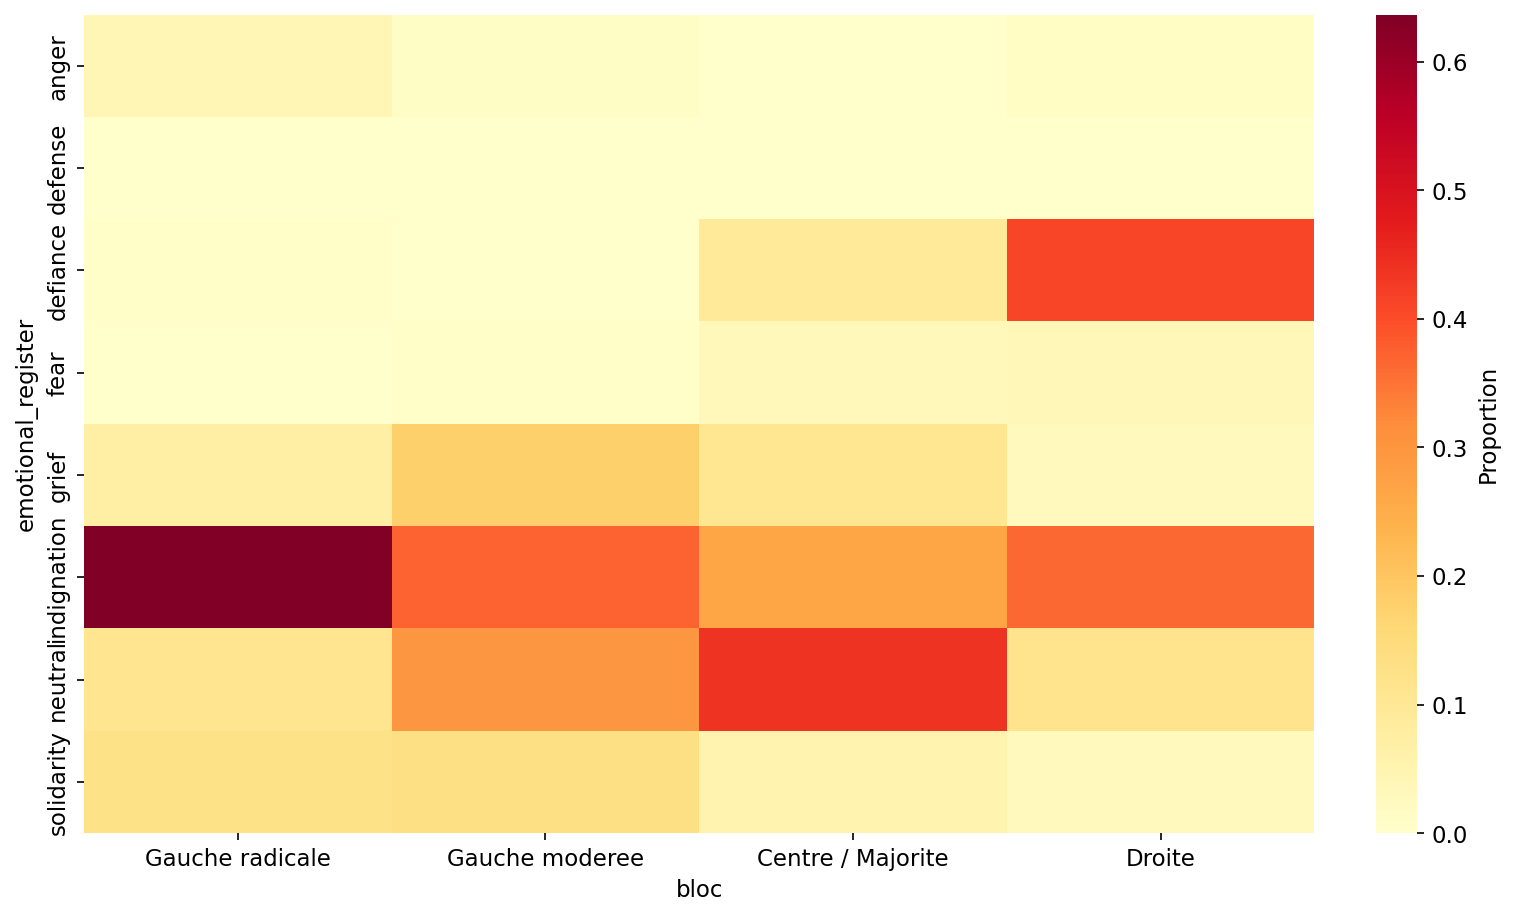

In [7]:
emo_col = 'emotional_register' if 'emotional_register' in df_v4.columns else ('emotional_reg' if 'emotional_reg' in df_v4.columns else None)
if emo_col and emo_col in df_v4.columns:
    emo_ct = pd.crosstab(df_v4['bloc'], df_v4[emo_col])
    emo_ct = emo_ct.reindex(BLOC_ORDER).fillna(0)
    emo_ct_norm = emo_ct.div(emo_ct.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(emo_ct_norm.T, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Proportion'})
    save('fig45_heatmap_registres')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.text(0.5, 0.5, 'Registres non disponibles', ha='center', va='center')
    save('fig45_heatmap_registres')

## Fig 47 : Frames v3 et v4 (2 panels)

Pour chaque bloc, on identifie le registre émotionnel le plus fréquent et la part de textes qu’il représente. Cette synthèse illustre la congruence entre position politique et ton du discours.

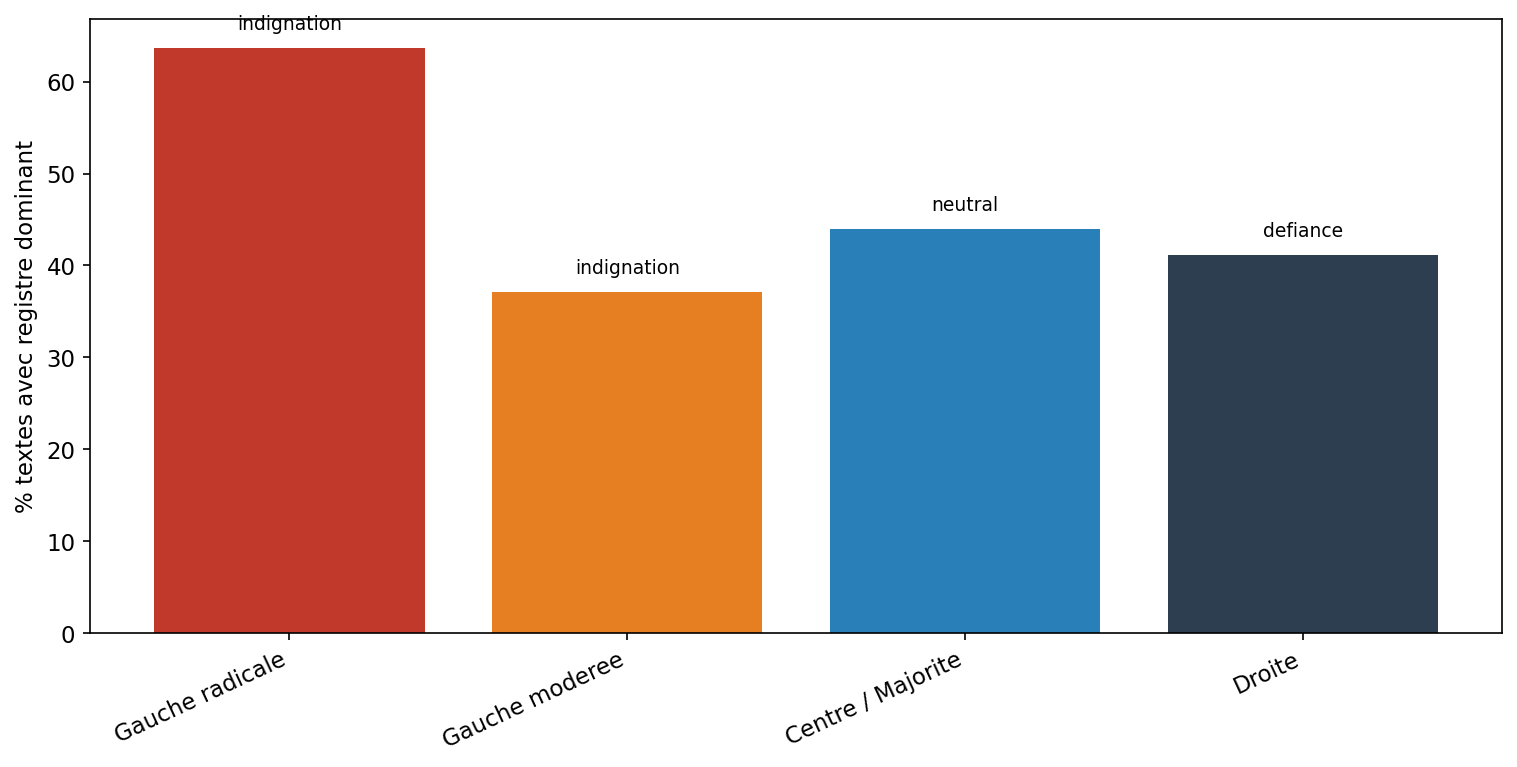

In [8]:
emo_col = 'emotional_register' if 'emotional_register' in df_v4.columns else ('emotional_reg' if 'emotional_reg' in df_v4.columns else None)
if emo_col and emo_col in df_v4.columns:
    dominant = df_v4[df_v4['bloc'].isin(BLOC_ORDER)].groupby('bloc')[emo_col].apply(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.value_counts().index[0]).reindex(BLOC_ORDER)
    counts = df_v4[df_v4['bloc'].isin(BLOC_ORDER)].groupby('bloc')[emo_col].apply(lambda x: x.value_counts().iloc[0] / len(x) * 100)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(dominant.index, counts.reindex(BLOC_ORDER).values, color=[BLOC_COLORS[b] for b in BLOC_ORDER])
    ax.set_ylabel('% textes avec registre dominant')
    plt.xticks(rotation=25, ha='right')
    for i, (b, r) in enumerate(dominant.items()):
        ax.text(i, counts.get(b, 0) + 2, str(r), ha='center', fontsize=9)
    save('fig46_registre_dominant')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(BLOC_ORDER, df[df['bloc'].isin(BLOC_ORDER)].groupby('bloc').size().reindex(BLOC_ORDER).values, color=[BLOC_COLORS[b] for b in BLOC_ORDER])
    save('fig46_registre_dominant')

In [9]:
# Fig 47 : Frames v3 et v4 (2 panels)
frames_path = RES_DIR / "frames_par_bloc.csv"
if frames_path.exists():
    frm = pd.read_csv(frames_path)
    if "version" in frm.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ix, ver in enumerate(["v3", "v4"]):
            sub = frm[frm["version"] == ver]
            piv = sub.pivot_table(index="bloc", columns="frame", values="pct")
            piv = piv.reindex([b for b in BLOC_ORDER if b in piv.index])
            piv.plot(kind="bar", stacked=True, ax=axes[ix], colormap="tab10")
            axes[ix].set_title(f"Frames {ver}")
            axes[ix].legend(bbox_to_anchor=(1.02, 1), fontsize=8)
            axes[ix].set_xticklabels(axes[ix].get_xticklabels(), rotation=25, ha="right")
        save("fig47_frames_v3_v4")

Chaque bloc présente un registre émotionnel dominant distinct ; la congruence entre position politique et ton renforce la cohérence identitaire du discours.